In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('breast-cancer.csv')
df.drop(columns=['id'], inplace=True)
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.reset_index(drop=True, inplace=True)
patient_idx = np.arange(len(df))

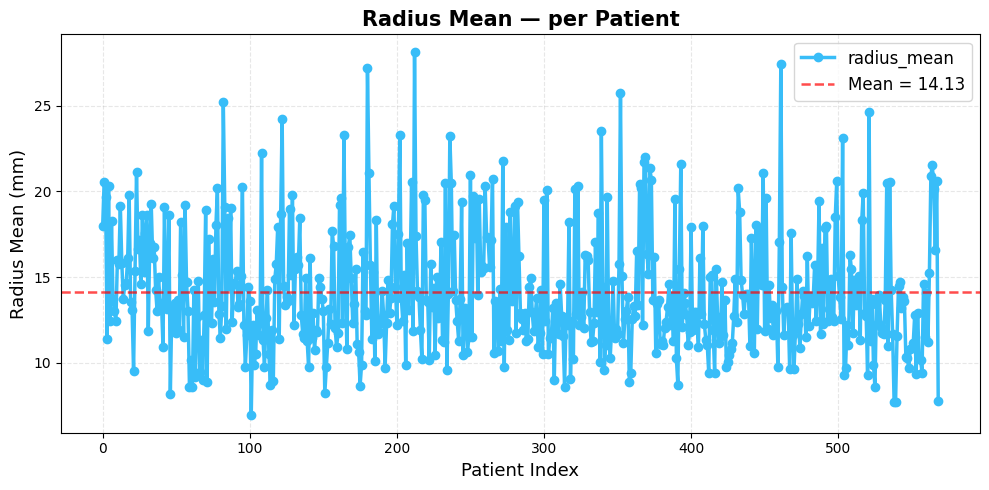

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(patient_idx, df['radius_mean'],
        color='#38bdf8', linewidth=2.5,
        marker='o', markersize=6,
        linestyle='-', label='radius_mean')

mean_val = df['radius_mean'].mean()
ax.axhline(mean_val, color='red', linestyle='--',
           linewidth=1.8, alpha=0.7,
           label=f'Mean = {mean_val:.2f}')

ax.set_title('Radius Mean — per Patient', fontsize=15, fontweight='bold')
ax.set_xlabel('Patient Index', fontsize=13)
ax.set_ylabel('Radius Mean (mm)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

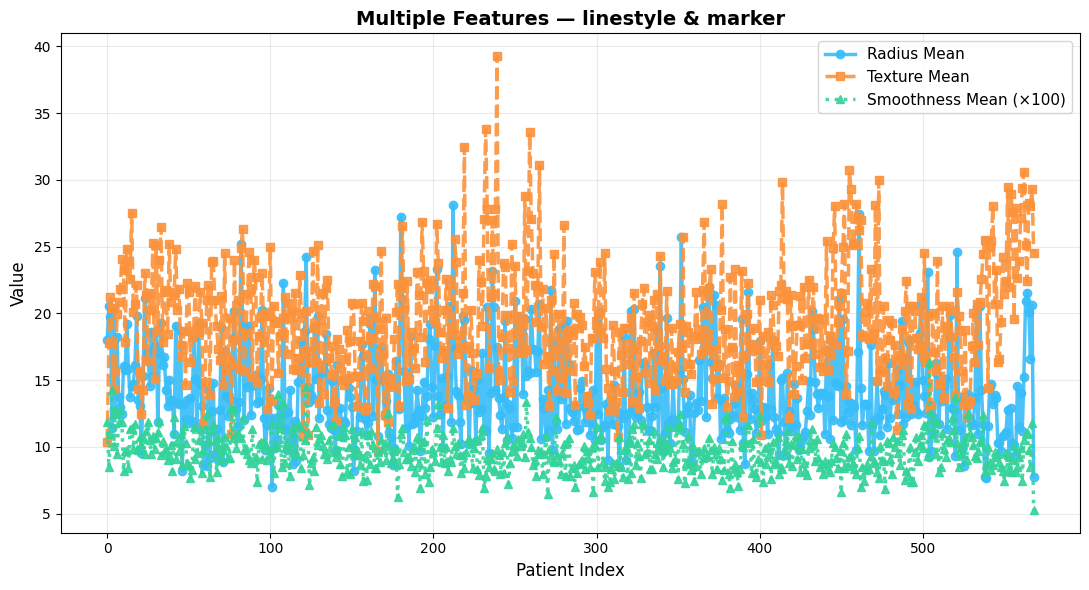

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

features = [
    ('radius_mean',     '#38bdf8', '-',  'o', 'Radius Mean'),
    ('texture_mean',    '#fb923c', '--', 's', 'Texture Mean'),
    ('smoothness_mean', '#34d399', ':',  '^', 'Smoothness Mean (×100)'),
]

for col, color, ls, marker, label in features:
    values = df[col] * 100 if 'smooth' in col else df[col]
    ax.plot(patient_idx, values,
            color=color, linewidth=2.5,
            linestyle=ls, marker=marker,
            markersize=6, alpha=0.9, label=label)

ax.set_title('Multiple Features — linestyle & marker', fontsize=14, fontweight='bold')
ax.set_xlabel('Patient Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

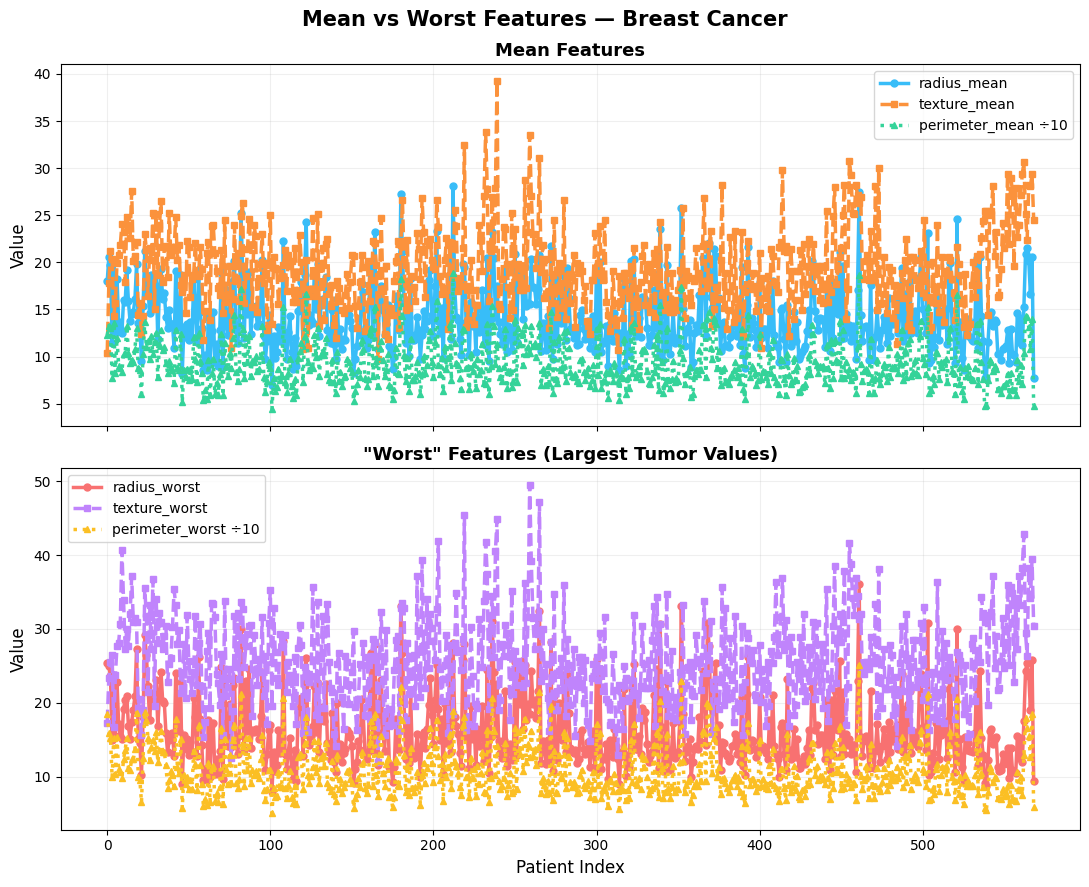

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Top panel — mean features
ax1.plot(patient_idx, df['radius_mean'],
         color='#38bdf8', lw=2.5, marker='o', ms=5, label='radius_mean')
ax1.plot(patient_idx, df['texture_mean'],
         color='#fb923c', lw=2.5, marker='s', ms=5, linestyle='--', label='texture_mean')
ax1.plot(patient_idx, df['perimeter_mean'] / 10,
         color='#34d399', lw=2.5, marker='^', ms=5, linestyle=':', label='perimeter_mean ÷10')
ax1.set_title('Mean Features', fontsize=13, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.2)

# Bottom panel — worst features
ax2.plot(patient_idx, df['radius_worst'],
         color='#f87171', lw=2.5, marker='o', ms=5, label='radius_worst')
ax2.plot(patient_idx, df['texture_worst'],
         color='#c084fc', lw=2.5, marker='s', ms=5, linestyle='--', label='texture_worst')
ax2.plot(patient_idx, df['perimeter_worst'] / 10,
         color='#fbbf24', lw=2.5, marker='^', ms=5, linestyle=':', label='perimeter_worst ÷10')
ax2.set_title('"Worst" Features (Largest Tumor Values)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Patient Index', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.2)

fig.suptitle('Mean vs Worst Features — Breast Cancer', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()